# Multidimensional array operations

we mostly want to get used to:
* using numpy functions for all simple operations
* get more comfortable with the axis parameter of these functions


### Functions working along axes
* sum, cumsum
* min/max
* mean (arthimetic mean / average)
* prod, cumprod (product)
* diff (differnces between consecutive elements, super useful)
* norm (np.linalg.norm; btw. rememver: distance between u, v is norm(u-v))

note that if A is an np.array we can also say A.sum(axis=0), A.mean()... 

### Summing things up along selected axes

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
A = np.array([[1,2,3,4], [4,5,6,7], [8,9,10,11]])

print(A)
print(A.shape)
print("num elements along axis 0:", A.shape[0])
print("num elements along axis 1:", A.shape[1])

[[ 1  2  3  4]
 [ 4  5  6  7]
 [ 8  9 10 11]]
(3, 4)
num elements along axis 0: 3
num elements along axis 1: 4


### Back to indexing

In [7]:
i = 0
# axis 0 1
print(A[i,:]) # indexing (selecting) along the axis 0 gives the i-th row
print(A[:, i]) # indexing (selecting) along the axis 1 gives the i-th column

[1 2 3 4]
[1 4 8]


### Cumulative sum (very useful)
this operation tracks the consecutive summation steps of X, namely the i-th element of the result is 
$X[0] + X[1] + \dots + X[k] = \sum_{i=0}^k X[i]$.

> the result has the same shape as the input!
> it's crucial that it's computed in a smart way -- see below

In [13]:
print(A)
CS0 = np.cumsum(A, axis=0) # sum up rows (go vertically)
print("cumsum in axis 0\n", CS0)

CS1 = np.cumsum(A, axis =1) # sum up colums (go horizontally)
print("cumsum in axis 1\n", CS1)

CS = np.cumsum(A) # sum up everything
print(CS) # NOT WHAT WE WANT

[[ 1  2  3  4]
 [ 4  5  6  7]
 [ 8  9 10 11]]
cumsum in axis 0
 [[ 1  2  3  4]
 [ 5  7  9 11]
 [13 16 19 22]]
cumsum in axis 1
 [[ 1  3  6 10]
 [ 4  9 15 22]
 [ 8 17 27 38]]
[ 1  3  6 10 14 19 25 32 40 49 59 70]


### Compulsory (for me) note about efficiency

In [15]:
L = np.random.rand(3*10**5)

# this functino generates random numbers between 0 and 1 from a uniform distribution.
# np.random.rand(n) -> returns n random floats in [0,1)


# create a numpy array
# with 300,000 random floating-point numbers
# each number between 0 (inclusive) and 1 (exclusive)

In [16]:
%time print(np.cumsum(L)) #fast

[7.24124791e-01 1.24529554e+00 2.10680644e+00 ... 1.49790980e+05
 1.49791160e+05 1.49791878e+05]
CPU times: user 2.21 ms, sys: 4.52 ms, total: 6.72 ms
Wall time: 15.1 ms


In [17]:
%time print(np.array([np.sum(L[:i+1]) for i in range(len(L))]))

[7.24124791e-01 1.24529554e+00 2.10680644e+00 ... 1.49790980e+05
 1.49791160e+05 1.49791878e+05]
CPU times: user 8.36 s, sys: 81.8 ms, total: 8.44 s
Wall time: 8.51 s


### Optional: np.diff

given an array A, np.diff computes the finite difference, namely A[i + 1] - A[i] for each index i.
in other words, computes the differences of all adjacent elemtns

> keep in mind that the result will ahve length smaller by 1 than A
> extra: optionally computes the n-th fininte difference.

### Trick: another way of selecting many rows of an array

we saw we can select a subarray by indexing with an array/list with True/False value for each row.

we can also select the indices of wors that we like directly.

In [19]:
M = np.array([[1,2,3], [4,5,6], [7,8,9]])

print(M, '\n')
print(M[[1,0]], '\n') # index with a list not a tuple (np.array works too!
print(M[[0,1,0,2,1,0,2,-1]], '\n') # we can repeat the indices

# so you swapped the rows

[[1 2 3]
 [4 5 6]
 [7 8 9]] 

[[4 5 6]
 [1 2 3]] 

[[1 2 3]
 [4 5 6]
 [1 2 3]
 [7 8 9]
 [4 5 6]
 [1 2 3]
 [7 8 9]
 [7 8 9]] 



### np.arg*

there is a bunch of useful numpy functions that return an index(or indices).
For example, the index of the min(or max) element in an np.array or list.

> It's called armin after a mathematical notation, $\arg\,min_x f(x)$ which returns the set of all minima of a $f$. So it's closely related but not the same.

In [ ]:
A = np.array([10, 5, 30]) # this creates a vector (a 1D array - just one row of numbers)

index_of_smallest_element = np.argmin(A)
value_of_smallest_element = A[index_of_smallest_element]
print(f'''the smallest element of A is at index {index_of_smallest_element} its value is {value_of_smallest_element}''')

the smallest element of A is at index 1 its value is 5


argmin = **argument of the minimum**
- it finds the position(index) of the smallest number, not the number itselt


In [24]:
B = np.array([1, 5, -1, 3])

index_of_biggest_element = np.argmax(B)
value_of_biggest_elements = B[index_of_biggest_element]
print(f'the biggest lement of B is at index {index_of_biggest_element} its value is {value_of_biggest_elements}')

the biggest lement of B is at index 1 its value is 5


argmax = argument of the maximum
* it finds the position(index) of the biggest number, not the number itself

### Bonus: generating directions uniformally at random

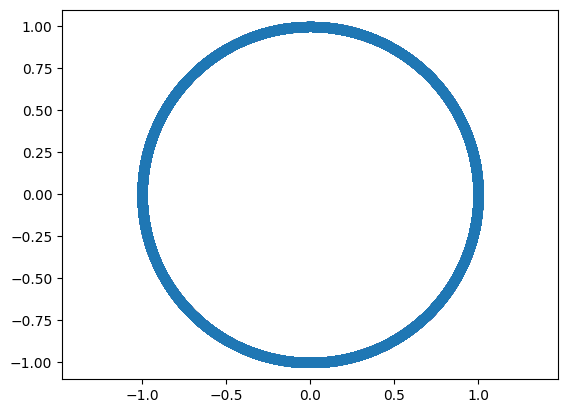

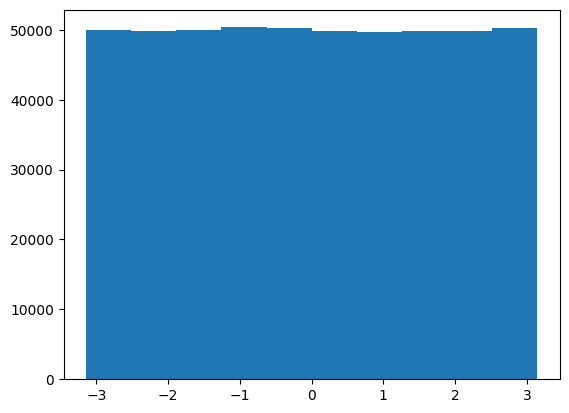

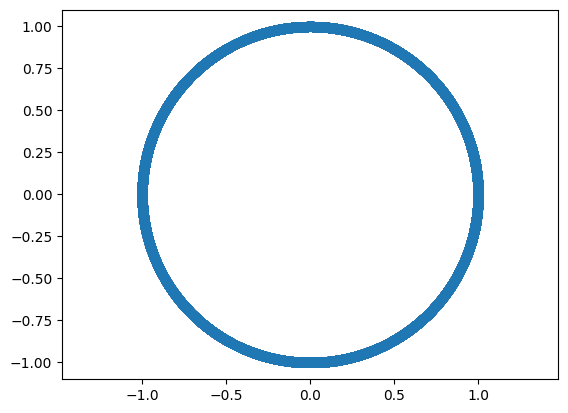

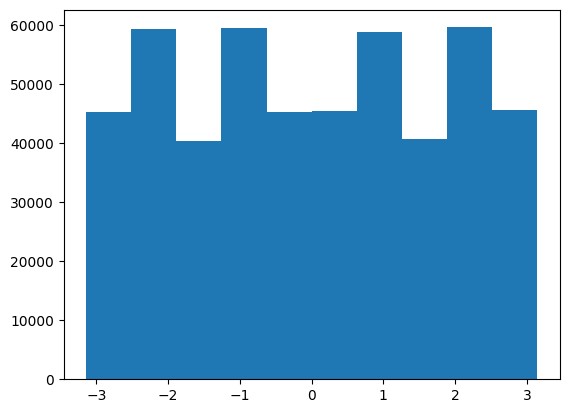

In [31]:
# generating directions uniformally at random

# it's about generating random directions (like arrow pointing in random directinos on a 2D plane)


def gen_directions_uniform(n):
    D = np.random.randn(n,2)
    D /= np.linalg.norm(D, axis=1, keepdims=True)
    return D

def gen_directions_bad(n):
    D = np.random.rand(n,2)*2-1
    D /= np.linalg.norm(D, axis=1, keepdims=True)
    return D
N = 500_000
A = gen_directions_uniform(N)
B = gen_directions_bad(N)

for D in A,B:
    plt.axis('equal')
    plt.scatter(*D.T, alpha=0.01)
    plt.show()
    plt.hist(np.arctan2(*D.T))
    plt.show()

#### get directions uniforms
##### np.random.randn(n,2)
- creates n rows, 2 colums of **random numbers**
- each row = one point [x,y] randomly placed in 2D place

##### np.linalg.norm(D, axis=1, keepdims=True)
- norm = the length of each row vector
- for a vector [x,y], length root(x^2+y^2) <- this is linear algebra
- axis=1 = calculate length **per row** (not the whole matrix)
- keepdims=True = keep the shape so division works correctly.

##### D /= ... (divide by the norm)
- this shrinks every vecotor to length 1
- called **normalizing** now every point sits exaclty on the circle
- direction is kept, but length becomes 1


#### gen_directions_bad(n)  why bad?

- rand = random numbers between 0 and 1 
- *2-1  = shifts them to be between -1 and 1
- this picks random points inside a square

**then it normalizes the same way** -> pushes points onto the circle

then why is bad?
> beause the square has corners - points near corners are **more likely** to picked,
so after noramlizing, directions near 45/135/225/315 degree appear **more often** then others.
not truly uniforms.

In [32]:
# Square corners → bias           Circle → no bias
#       ■                               ○
#   corners get                   every direction
#   overrepresented               equally likely

In [34]:
# for D in A, B:               # run the same plots for both A and B
#     plt.axis('equal')        # make x and y axis same scale (circle looks round)
#     plt.scatter(*D.T, alpha=0.01)   # scatter plot of all points
#     plt.show()
#     plt.hist(np.arctan2(*D.T))      # histogram of angles
#     plt.show()

# *D.T 
# D.T = transpose of D > flips rows and columns
# before transpose; each rows = [x,y]
# after transpose; first row = all x values, second row = all y values
# * = unpacks it, so plt.scatter gets x values and y values separately.

##### rand
* range = 0 to 1
* distribution = uniform (all equal)
* shape = flat

> rand(the square) is not round, that's why it causes the bias!

##### randn
* range = any number (negative infinity to positive infinity)
* distribution = bell curve (middle is common)
* shape = curved/hump

### Sorting with np.argsort
np.arrays don't play well with standard sorting (e.g. using sorted).

Often we will do this instead:
- Extract the **keys** to compare (often using some numpy functions, for example to compute the norm).

> Sometimes the keys will be just the original array...

- np.argsort the keys which returns an **array of indices** (i.e. a permutation) that specify the sorted order.
- Index the original array using these indices.

> Yes, this seems silly, but is very efficient.

> Extra: There is also np.argpartition which is faster than sorting and useful when you're asked for top-k elements but don't want to sort them all.


In [35]:
R = np.array([5,3,2])
inds = np.argsort(R)
print("inds:", inds, "\nsorted R:", R[inds])

inds: [2 1 0] 
sorted R: [2 3 5]


In [ ]:
# sorting rows of a matrix by their length (norm)
D = np.random.rand(10, 2) # we have 10 randm 2D points. we want to sort them from shortest to longest vector
norms = np.linalg.norm(D, axis=1) # axis 1 = per row
inds = np.argsort(norms) # argsort = like argmin but for all elements
print(inds)
print(norms[inds])
R = D[inds]
np.linalg.norm(R, axis=1)

[6 5 3 9 4 1 0 7 2 8]
[0.19678527 0.43947653 0.5411054  0.57045941 0.90666769 0.92455854
 0.97422344 1.00342773 1.04329051 1.15405527]


array([0.19678527, 0.43947653, 0.5411054 , 0.57045941, 0.90666769,
       0.92455854, 0.97422344, 1.00342773, 1.04329051, 1.15405527])

* np.argmin(A) : index of the smallest value
* np.argsort(A) : indices of all values in sorted order
* A[inds] = reorder A using those indices (fancy indexing)

### Example: sorting vectors by their norm

In [56]:
# more complex example
R = np.random.rand(5,2) # random number between 0 and 1, creates 5 rows 2 columns
print(R)
norms = np.linalg.norm(R, axis=1) #  calculate the norm across each row(per row)
print("norms to sort by:\n", norms)
sorted_indices = np.argsort(norms)
print('permutation:', sorted_indices)

R_sorted_by_norms = R[sorted_indices] 
# fancy indexing: reorder the rows of R, using the sorted indices
# so, pick rows in order given by sorted_indices
# R sorted from smallest norm -> largest norm
print("sorted:\n", R_sorted_by_norms)
print("norms:\n", np.linalg.norm(R_sorted_by_norms, axis=1))

[[0.86040353 0.16164568]
 [0.47799797 0.18857107]
 [0.82331568 0.3803982 ]
 [0.51830549 0.77986145]
 [0.16738054 0.64610202]]
norms to sort by:
 [0.8754562  0.51384931 0.90694625 0.93638906 0.66743094]
permutation: [1 4 0 2 3]
sorted:
 [[0.47799797 0.18857107]
 [0.16738054 0.64610202]
 [0.86040353 0.16164568]
 [0.82331568 0.3803982 ]
 [0.51830549 0.77986145]]
norms:
 [0.51384931 0.66743094 0.8754562  0.90694625 0.93638906]
